# Credit Card Fraud Detection Using Machine Learning

## Business Problem

Financial institutions process millions of transactions every day, and fraudulent transactions can result in significant financial losses.

The objective of this project is to build a machine learning model capable of identifying potentially fraudulent credit card transactions.

## Goal

Develop and evaluate classification models that distinguish between legitimate and fraudulent transactions while considering the highly imbalanced nature of the dataset.

## Models

- Logistic Regression
- Random Forest Classifier


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [4]:
df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
df.shape

(39702, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39702 entries, 0 to 39701
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    39702 non-null  int64  
 1   V1      39702 non-null  float64
 2   V2      39702 non-null  float64
 3   V3      39702 non-null  float64
 4   V4      39702 non-null  float64
 5   V5      39702 non-null  float64
 6   V6      39702 non-null  float64
 7   V7      39702 non-null  float64
 8   V8      39702 non-null  float64
 9   V9      39702 non-null  float64
 10  V10     39702 non-null  float64
 11  V11     39702 non-null  float64
 12  V12     39702 non-null  float64
 13  V13     39701 non-null  float64
 14  V14     39701 non-null  float64
 15  V15     39701 non-null  float64
 16  V16     39701 non-null  float64
 17  V17     39701 non-null  float64
 18  V18     39701 non-null  float64
 19  V19     39701 non-null  float64
 20  V20     39701 non-null  float64
 21  V21     39701 non-null  float64
 22

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,39702.000000,...,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000,39701.000000
mean,25502.432497,-0.213932,0.051942,0.713780,0.189431,-0.231083,0.100915,-0.112981,0.041731,0.214179,...,-0.029662,-0.112320,-0.040265,0.007226,0.136322,0.023181,0.008097,0.004171,87.445979,0.002620
std,12626.308343,1.831757,1.548373,1.506728,1.399784,1.379431,1.304722,1.244260,1.222742,1.225147,...,0.750969,0.638109,0.551644,0.593281,0.435481,0.504830,0.385255,0.298453,234.567447,0.051115
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,14678.500000,-0.967117,-0.525207,0.233522,-0.717668,-0.835646,-0.638647,-0.597725,-0.152448,-0.555904,...,-0.236834,-0.534709,-0.178626,-0.325662,-0.128065,-0.330371,-0.063315,-0.006938,7.300000,0.000000
50%,30598.500000,-0.233669,0.101393,0.818163,0.185015,-0.267851,-0.158696,-0.073409,0.048385,0.091864,...,-0.077298,-0.086811,-0.051646,0.060796,0.176097,-0.063305,0.008394,0.021454,23.430000,0.000000
75%,35625.000000,1.160708,0.743741,1.447844,1.071347,0.297049,0.487010,0.433877,0.314947,0.930712,...,0.100244,0.299013,0.076971,0.399378,0.421048,0.304110,0.085116,0.075965,79.000000,0.000000
max,39929.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 18


In [10]:
df["Class"].value_counts()

,count
Class,
0.0,39597
1.0,104


In [11]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraud Transactions: {fraud_percentage:.3f}%")

Fraud Transactions: 0.262%


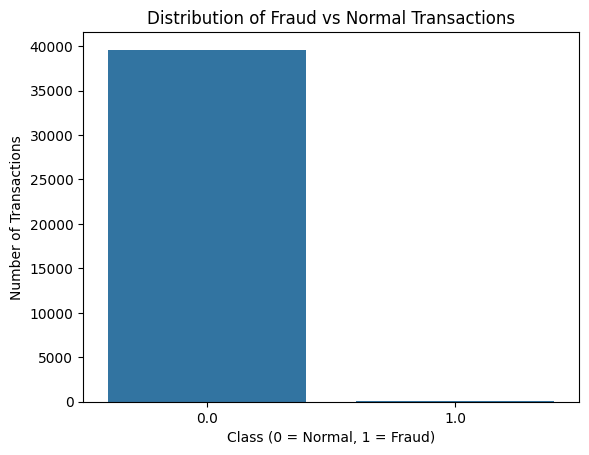

In [12]:
sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

#Accuracy alone is misleading.
A model that predicts every transaction as normal could achieve very high accuracy but detect zero fraud cases.

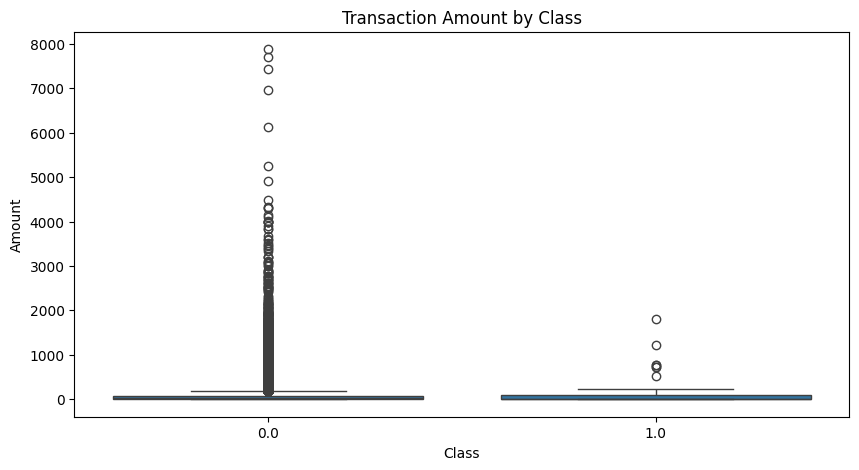

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")

plt.show()

In [14]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,39597.0,87.420700,234.514383,0.0,7.42,23.500,79.00,7879.42
1.0,104.0,97.070769,255.012160,0.0,1.00,3.775,99.99,1809.68


In [24]:
print(df["Class"].value_counts(dropna=False))

Class
0.0    39597
1.0      104
NaN        1
Name: count, dtype: int64


In [25]:
df = df.dropna(subset=["Class"])

In [26]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [28]:
scaler = StandardScaler()

X_train[["Amount", "Time"]] = scaler.fit_transform(
    X_train[["Amount", "Time"]]
)

X_test[["Amount", "Time"]] = scaler.transform(
    X_test[["Amount", "Time"]]
)

#Model 1 — Logistic Regression

In [29]:
class_weight="balanced"

In [30]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [31]:
y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      7920
         1.0       0.11      0.90      0.20        21

    accuracy                           0.98      7941
   macro avg       0.56      0.94      0.60      7941
weighted avg       1.00      0.98      0.99      7941



In [33]:
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Precision: 0.11377245508982035
Recall: 0.9047619047619048
F1 Score: 0.20212765957446807
ROC-AUC: 0.9494829244829246


#Model 2 — Random Forest

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [35]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [36]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7920
         1.0       0.94      0.76      0.84        21

    accuracy                           1.00      7941
   macro avg       0.97      0.88      0.92      7941
weighted avg       1.00      1.00      1.00      7941



#Compare Models

In [37]:
def evaluate_model(y_true, y_pred, y_prob):

    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [38]:
lr_results = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf
)

In [39]:
results = pd.DataFrame(
    [lr_results, rf_results],
    index=["Logistic Regression", "Random Forest"]
)

results

,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.113772,0.904762,0.202128,0.949483
Random Forest,0.941176,0.761905,0.842105,0.975565


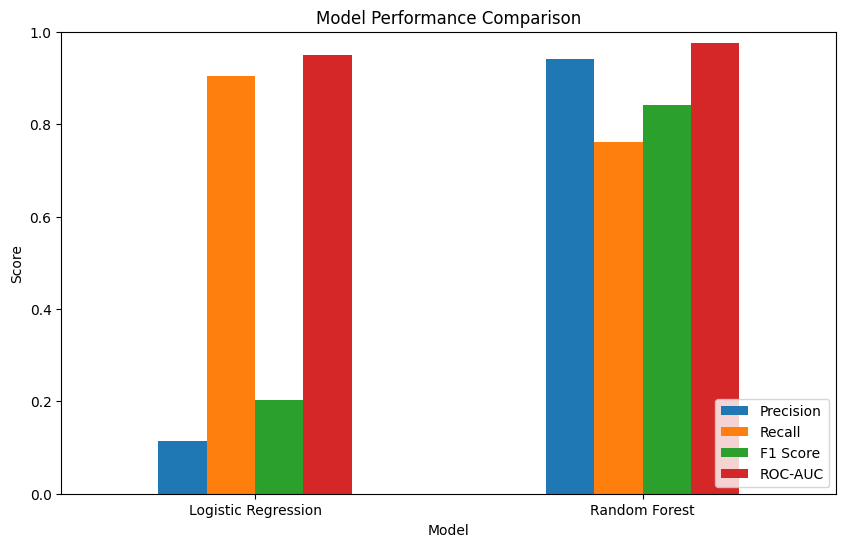

In [47]:
results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

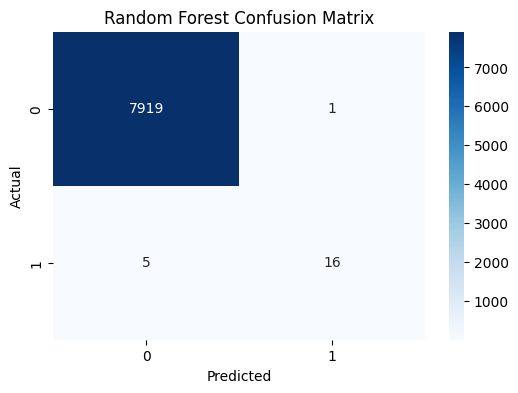

In [40]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.187060
4,V4,0.118883
10,V10,0.111152
3,V3,0.101102
12,V12,0.097526
2,V2,0.068891
17,V17,0.064178
11,V11,0.040483
16,V16,0.036090
6,V6,0.027242


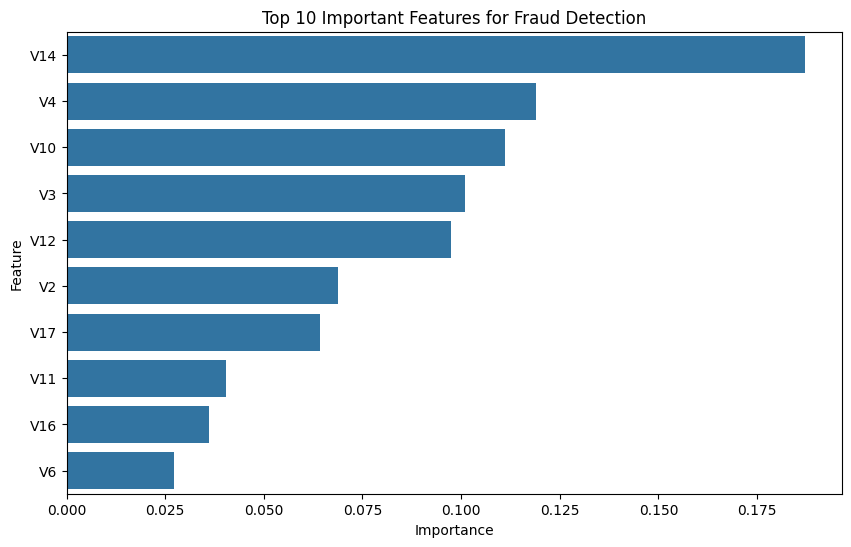

In [43]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Fraud Detection")

plt.show()


**Insight 1**

Fraudulent transactions represent a very small percentage of total transactions, making the dataset highly imbalanced.

**Insight 2**

Accuracy is not an appropriate standalone metric because a model can achieve high accuracy while failing to detect fraudulent transactions.

**Insight 3**

Recall is particularly important in fraud detection because missing a fraudulent transaction can result in financial losses.

**Insight 4**

Precision is also important because incorrectly flagging legitimate transactions may negatively affect customer experience.

**Insight 5**

The best model should balance fraud detection capability and false positive rates.